<a href="https://colab.research.google.com/github/chuancao26/islp/blob/main/LinearRegression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install d2l --no-deps

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 111.7/111.7 kB 10.0 MB/s eta 0:00:00


In [53]:
%matplotlib inline
import random
from d2l import torch as d2l
import time
import numpy as np
import torch
from torch import nn

In [3]:
class SyntheticRegressionData(d2l.DataModule):
    """Synthetic data for linear regression."""
    def __init__(self, w, b, noise=0.01, num_train=1000, num_val=1000,
                 batch_size=32):
        super().__init__()
        self.save_hyperparameters()
        n = num_train + num_val
        self.X = torch.randn(n, len(w))
        noise = torch.randn(n, 1) * noise
        self.y = torch.matmul(self.X, w.reshape((-1, 1))) + b + noise


In [4]:
data = SyntheticRegressionData(w=torch.tensor([2, -3.4]), b=4.2)

In [5]:
print('features:', data.X[0],'\nlabel:', data.y[0])


features: tensor([ 1.3293, -0.2984]) 
label: tensor([7.8750])


ya tenemos la data necesaria para aplicar el modelo de machine learning mediante el uso del gradiente descendiente. y un batch de datos de entreamiento para cada iteracion


In [6]:
@d2l.add_to_class(SyntheticRegressionData)
def get_dataloader(self, train):
    if train:
        indices = list(range(0, self.num_train))
        # The examples are read in random order
        random.shuffle(indices)
    else:
        indices = list(range(self.num_train, self.num_train+self.num_val))
    for i in range(0, len(indices), self.batch_size):
        batch_indices = torch.tensor(indices[i: i+self.batch_size])
        yield self.X[batch_indices], self.y[batch_indices]


vamos a ver el primer elemento de entreamiento en donde debemos de recordar que ya se hizo una definicion de las estructuras un capitulo antes, en donde esta el modulo de datos y la posterior inyeccion de get_dataloader con el uso de add_to_class

Vamos a mejora la eficiencia del codigo ya que en el enfoque anterior necesitamos cargar los datos a memoria multiples veces lo cual no tiene sentido ya que solo usamos el batch necesario.

In [8]:
@d2l.add_to_class(d2l.DataModule)
def get_tensorloader(self, tensors, train, indices=slice(0, None)):
    tensors = tuple(a[indices] for a in tensors)
    dataset = torch.utils.data.TensorDataset(*tensors)
    return torch.utils.data.DataLoader(dataset, self.batch_size,
                                       shuffle=train)

@d2l.add_to_class(SyntheticRegressionData)
def get_dataloader(self, train):
    i = slice(0, self.num_train) if train else slice(self.num_train, None)
    return self.get_tensorloader((self.X, self.y), train, i)

In [9]:
X, y = next(iter(data.train_dataloader()))

En caso de que la cantidad de elementos (n) no sea multiplo del batchsize podemos agregar un parametro en el dataloader de torch en el cual podemos descartar el ultimo batch que no estara completo. Esto dependera de nuestras necesidades y el algoritmo entrenado.

In [10]:
class RegressionDataOnFly(d2l.HyperParameters):
  def __init__(self, w, b, noise=0.01, batch_size=32, n=1000):
    self.save_hyperparameters()
    self.w = self.w.reshape(-1, 1)
  def get_dataloader(self):
    for _ in range(self.n // self.batch_size):
      X = torch.randn(self.batch_size, self.w.shape[0])
      y = torch.matmul(X, self.w) + self.b + self.noise * torch.randn(self.batch_size, 1)
      yield X, y






In [11]:
w = torch.tensor([2, -3.4])
b = 4.2
data = RegressionDataOnFly(w, b)
X, y = next(iter(data.get_dataloader()))


## Trainer

In [160]:
class Trainer(d2l.HyperParameters):
    """The base class for training models with data."""
    def __init__(self, max_epochs, num_gpus=0, gradient_clip_val=0):
        self.save_hyperparameters()
        assert num_gpus == 0, 'No GPU support yet'

    def prepare_data(self, data):
        self.train_dataloader = data.train_dataloader()
        self.val_dataloader = data.val_dataloader()
        self.num_train_batches = len(self.train_dataloader)
        self.num_val_batches = (len(self.val_dataloader)
                                if self.val_dataloader is not None else 0)

    def prepare_model(self, model):
        model.trainer = self
        model.board.xlim = [0, self.max_epochs]
        self.model = model

    def fit(self, model, data):
        self.prepare_data(data)
        self.prepare_model(model)
        self.optim = model.configure_optimizers()
        self.epoch = 0
        self.train_batch_idx = 0
        self.val_batch_idx = 0
        for self.epoch in range(self.max_epochs):
            self.fit_epoch()

    def fit_epoch(self):
        raise NotImplementedError

## Defining the model

In [161]:
class LinearRegressionScratch(d2l.Module):
    """The linear regression model implemented from scratch."""
    def __init__(self, num_inputs, lr, sigma=0.01):
        super().__init__()
        self.save_hyperparameters()
        self.w = torch.normal(0, sigma, (num_inputs, 1), requires_grad=True)
        self.b = torch.zeros(1, requires_grad=True)

Ahora vamos a definir como se conectan los parametros

In [162]:
@d2l.add_to_class(LinearRegressionScratch)
def forward(self, X):
    return torch.matmul(X, self.w) + self.b


ahora vamos a definir la funcion de perdida

In [163]:
@d2l.add_to_class(LinearRegressionScratch)
def loss(self, y_hat, y):
    l = (y_hat - y) ** 2 / 2
    return l.mean()

## SGD

ahora vamos a definir el Stochastic Gradient descent

In [166]:
class SGD(d2l.HyperParameters):
    """Minibatch stochastic gradient descent."""
    def __init__(self, params, lr):
        self.save_hyperparameters()

    def step(self):
        for param in self.params:
            param -= self.lr * param.grad

    def zero_grad(self):
        for param in self.params:
            if param.grad is not None:
                param.grad.zero_()

se configura el optimizador


In [167]:
@d2l.add_to_class(LinearRegressionScratch)
def configure_optimizers(self):
    return SGD([self.w, self.b], self.lr)

In [186]:
@d2l.add_to_class(Trainer)
def prepare_batch(self, batch):
    return batch

@d2l.add_to_class(Trainer)
def fit_epoch(self):
    self.model.train()
    for batch in self.train_dataloader:
        loss = self.model.training_step(self.prepare_batch(batch))
        self.optim.zero_grad()
        with torch.no_grad():
            loss.backward()
            if self.gradient_clip_val > 0:  # To be discussed later
                self.clip_gradients(self.gradient_clip_val, self.model)
            self.optim.step()
        self.train_batch_idx += 1
    if self.val_dataloader is None:
        return
    self.model.eval()
    for batch in self.val_dataloader:
        with torch.no_grad():
            self.model.validation_step(self.prepare_batch(batch))
        self.val_batch_idx += 1

In [209]:
model = LinearRegressionScratch(2, lr=0.03)
data = d2l.SyntheticRegressionData(w=torch.tensor([2, -3.4]), b=4.2)



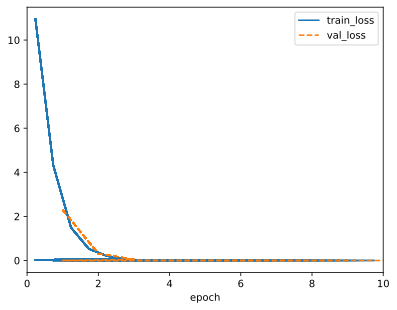

In [211]:
trainer = Trainer(max_epochs=10)
trainer.fit(model, data)

In [212]:
with torch.no_grad():
    print(f'error in estimating w: {data.w - model.w.reshape(data.w.shape)}')
    print(f'error in estimating b: {data.b - model.b}')

error in estimating w: tensor([ 0.0001, -0.0002])
error in estimating b: tensor([-0.0002])


In [202]:
from sklearn import linear_model as skl

linear = skl.LinearRegression()
linear.fit(data.X.numpy()[:1000], data.y.numpy()[:1000])

y_hat = linear.predict(data.X.numpy()[1000:])
np.mean((y_hat - data.y.numpy()[1000:]) ** 2)

np.float32(0.00010588849)

In [204]:
linear.coef_ - data.w.numpy()

array([[0.00059485, 0.00067616]], dtype=float32)

torch.Size([2000, 1])